# EDA guiado por hipotesis

Este notebook valida las hipotesis escritas por el equipo en `reports/01_hipotesis.md`.

Criterio de trabajo:
- No se generan hipotesis nuevas automaticamente.
- Se usan graficos y tests para contrastar las hipotesis existentes.
- Los resultados son un borrador tecnico: despues deben revisarse manualmente antes de convertirse en conclusiones finales.


In [22]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("../data/processed/datos_limpios.csv")
OUTPUT_DIR = Path("../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
blue = "steelblue"

TARGET = "Churn"


## Carga del dataset

In [23]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3.0,6,Debit Card,Female,3,3.0,Laptop & Accessory,2.0,Single,9.0,1.0,11,1,1,5,160.0
1,50002,1,12,Phone,1.0,8,UPI,Male,3,4.0,Mobile,3.0,Single,7.0,1.0,15,0,1,0,121.0
2,50003,1,3,Phone,1.0,30,Debit Card,Male,2,4.0,Mobile,3.0,Single,6.0,1.0,14,0,1,3,120.0
3,50004,1,0,Phone,3.0,15,Debit Card,Male,2,4.0,Laptop & Accessory,5.0,Single,8.0,0.0,23,0,1,3,134.0
4,50005,1,0,Phone,1.0,12,CC,Male,2,3.0,Mobile,5.0,Single,3.0,0.0,11,1,1,3,130.0


## Distribucion del target

Antes de validar hipotesis, miramos el peso relativo de churn y no churn para interpretar tasas y comparaciones.

In [24]:
target_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .to_frame("clientes")
    .assign(porcentaje=lambda x: (x["clientes"] / len(df) * 100).round(2))
)
target_summary

,clientes,porcentaje
Churn,,
0,4682,83.16
1,948,16.84


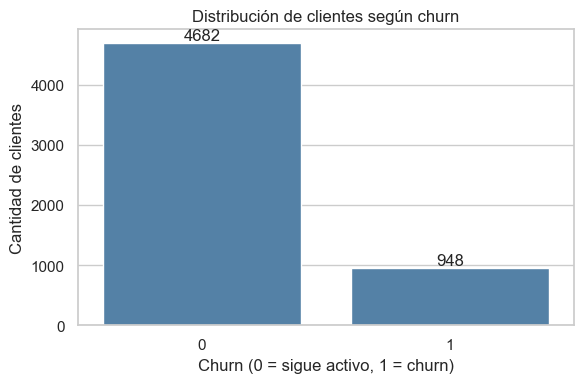

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x=TARGET,
    ax=ax,
    color=blue)

ax.set_title("Distribución de clientes según churn")
ax.set_xlabel("Churn (0 = sigue activo, 1 = churn)")
ax.set_ylabel("Cantidad de clientes")

for container in ax.containers:
    ax.bar_label(container)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "0.distribucion_churn.png", dpi=150)
plt.show()

## Funciones auxiliares para tests

- Variables numericas vs target binario: Mann-Whitney U, porque no asumimos normalidad.
- Variables categoricas u ordinales vs target binario: chi-cuadrado de independencia.
- Reportamos p-valor y tamaño de efecto para no depender solo de significancia estadistica.


In [26]:
def format_pvalue(p_value):
    return "< 0.001" if p_value < 0.001 else f"{p_value:.4f}"

def mann_whitney_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    churn_values = subset.loc[subset[target] == 1, feature]
    no_churn_values = subset.loc[subset[target] == 0, feature]
    statistic, p_value = stats.mannwhitneyu(churn_values, no_churn_values, alternative="two-sided")
    rank_biserial = (2 * statistic) / (len(churn_values) * len(no_churn_values)) - 1
    return {
        "feature": feature,
        "test": "Mann-Whitney U",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": rank_biserial,
        "mean_churn": churn_values.mean(),
        "mean_no_churn": no_churn_values.mean(),
        "median_churn": churn_values.median(),
        "median_no_churn": no_churn_values.median(),
    }


def cramers_v(table):
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan


def chi_square_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    table = pd.crosstab(subset[feature], subset[target])
    statistic, p_value, dof, expected = stats.chi2_contingency(table)
    return {
        "feature": feature,
        "test": "Chi-square",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": cramers_v(table),
        "dof": dof,
    }

## H1 - Tenure

**Hipotesis:** Los clientes con menor `Tenure` tienden a churnear mas.

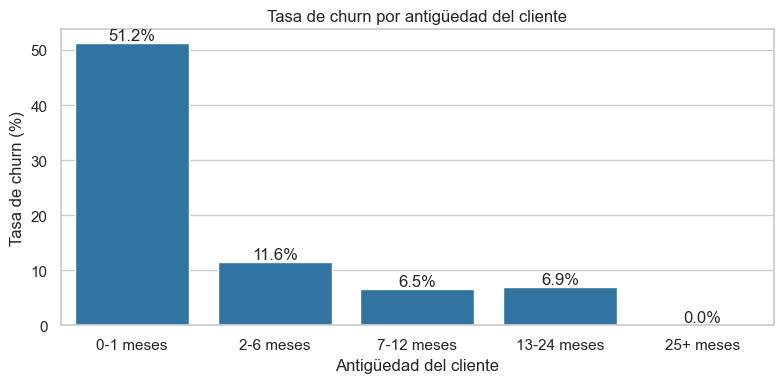

,tenure_segment,clientes,churn_rate,churn_rate_pct
0,0-1 meses,1231,0.511779,51.177904
1,2-6 meses,1082,0.115527,11.552680
2,7-12 meses,1399,0.065046,6.504646
3,13-24 meses,1489,0.068502,6.850235
4,25+ meses,429,0.000000,0.000000


In [27]:
df_tenure = df[["Tenure", "Churn"]].dropna().copy()

df_tenure["tenure_segment"] = pd.cut(
    df_tenure["Tenure"],
    bins=[-1, 1, 6, 12, 24, df_tenure["Tenure"].max()],
    labels=["0-1 meses", "2-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]
)

tenure_churn = (
    df_tenure
    .groupby("tenure_segment", observed=True)
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

tenure_churn["churn_rate_pct"] = tenure_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=tenure_churn,
    x="tenure_segment",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn por antigüedad del cliente")
ax.set_xlabel("Antigüedad del cliente")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H1_tenure_churn_rate_por_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

tenure_churn

In [28]:
h1_result = mann_whitney_test(df, "Tenure")
h1_result

{'feature': 'Tenure',
 'test': 'Mann-Whitney U',
 'n_used': 5630,
 'statistic': np.float64(864640.0),
 'p_value': np.float64(2.5205277689886073e-194),
 'effect_size': np.float64(-0.6103940578605198),
 'mean_churn': np.float64(3.5622362869198314),
 'mean_no_churn': np.float64(11.297308842375054),
 'median_churn': np.float64(1.0),
 'median_no_churn': np.float64(10.0)}

Los clientes que churnearon tienen una antigüedad mediana de 1 mes, mientras que los clientes activos tienen una mediana de 10 meses. Esto apoya la hipótesis de que los clientes nuevos son más propensos a abandonar, por lo que conviene reforzar acciones de onboarding y retención temprana.

## H2 - Complain

**Hipotesis:** Los clientes con reclamos tienden a churnear mas.

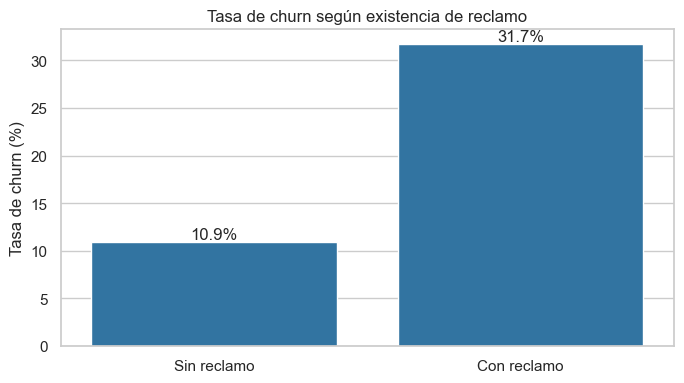

,Complain_label,clientes,churn_rate_pct
0,Sin reclamo,4026,10.928962
1,Con reclamo,1604,31.670823


In [39]:
complain_churn = (
    df.groupby("Complain")["Churn"]
    .agg(clientes="size", churn_rate="mean")
    .reset_index()
)

complain_churn["churn_rate_pct"] = complain_churn["churn_rate"] * 100
complain_churn["Complain_label"] = complain_churn["Complain"].map({
    0: "Sin reclamo",
    1: "Con reclamo"
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=complain_churn,
    x="Complain_label",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según existencia de reclamo")
ax.set_xlabel("")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H2_complain_churn_rate.png", dpi=150, bbox_inches="tight")
plt.show()

complain_churn[["Complain_label", "clientes", "churn_rate_pct"]]

In [37]:
h2_result = chi_square_test(df, "Complain")
h2_result

{'feature': 'Complain',
 'test': 'Chi-square',
 'n_used': 5630,
 'statistic': np.float64(350.92545525927073),
 'p_value': np.float64(2.6644609654641377e-78),
 'effect_size': np.float64(0.24966245605686588),
 'dof': 1}

Los clientes con reclamos presentan una tasa de churn de 31,7%, frente a 10,9% en clientes sin reclamos. Esto apoya la hipótesis de que una mala experiencia registrada mediante reclamos está asociada con mayor abandono.

## H3 - SatisfactionScore

**Hipotesis:** Los clientes con menor `SatisfactionScore` tienden a churnear mas.

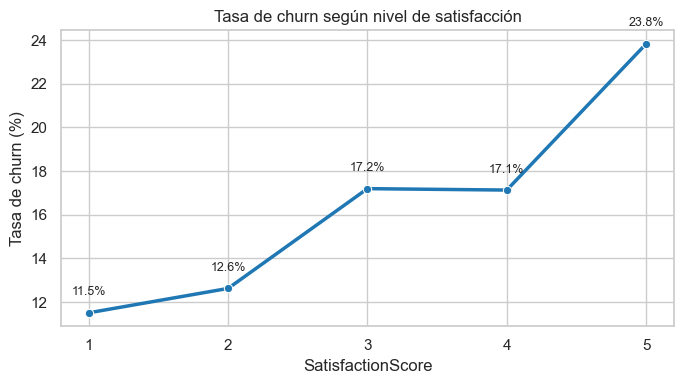

,SatisfactionScore,clientes,churn_rate_pct
0,1.0,1164,11.512027
1,2.0,586,12.627986
2,3.0,1698,17.196702
3,4.0,1074,17.132216
4,5.0,1108,23.826715


In [45]:
satisfaction_churn = (
    df.groupby("SatisfactionScore")["Churn"]
    .agg(clientes="size", churn_rate="mean")
    .reset_index()
)

satisfaction_churn["churn_rate_pct"] = satisfaction_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(
    data=satisfaction_churn,
    x="SatisfactionScore",
    y="churn_rate_pct",
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según nivel de satisfacción")
ax.set_xlabel("SatisfactionScore")
ax.set_ylabel("Tasa de churn (%)")
ax.set_xticks(sorted(df["SatisfactionScore"].unique()))

for _, row in satisfaction_churn.iterrows():
    ax.text(
        row["SatisfactionScore"],
        row["churn_rate_pct"] + 0.8,
        f"{row['churn_rate_pct']:.1f}%",
        ha="center",
        fontsize=9
    )

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H3_satisfaction_churn_rate_linea.png", dpi=150, bbox_inches="tight")
plt.show()

satisfaction_churn[["SatisfactionScore", "clientes", "churn_rate_pct"]]

In [40]:
h3_result = chi_square_test(df, "SatisfactionScore")
h3_result

{'feature': 'SatisfactionScore',
 'test': 'Chi-square',
 'n_used': 5630,
 'statistic': np.float64(69.8653884066938),
 'p_value': np.float64(2.4233349782737515e-14),
 'effect_size': np.float64(0.11139785834165415),
 'dof': 4}

Esperábamos que menor satisfacción implicara mayor churn, pero el patrón observado va en sentido contrario. Por eso, no conviene interpretar `SatisfactionScore` de manera lineal ni asumir que un score alto implica menor riesgo de abandono. Por el contrario, debemos estudiar por qué los clientes con mayor satisfacción tienen mayor churn rate lo cual es muy raro.

## H4 - OrderCount

**Hipotesis:** Los clientes con menor `OrderCount` tienden a churnear mas.

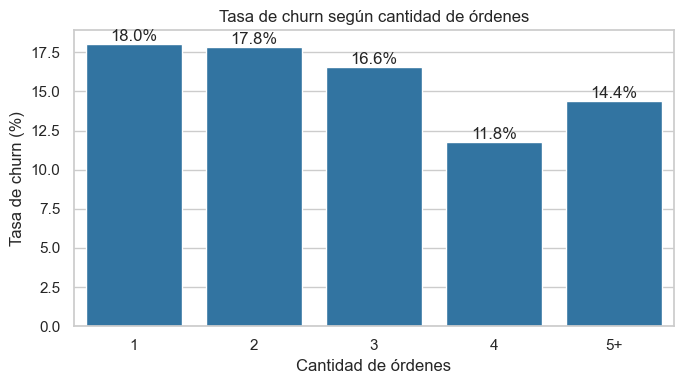

,order_group,clientes,churn_rate_pct
0,1,1767,17.996604
1,2,2100,17.809524
2,3,410,16.585366
3,4,246,11.788618
4,5+,1107,14.363144


In [50]:
df_order = df[["OrderCount", "Churn"]].dropna().copy()

df_order["order_group"] = df_order["OrderCount"].apply(
    lambda x: str(int(x)) if x < 5 else "5+"
)

order_churn = (
    df_order
    .groupby("order_group")
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

order_order = ["1", "2", "3", "4", "5+"]
order_churn["order_group"] = pd.Categorical(
    order_churn["order_group"],
    categories=order_order,
    ordered=True
)
order_churn = order_churn.sort_values("order_group")

order_churn["churn_rate_pct"] = order_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=order_churn,
    x="order_group",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según cantidad de órdenes")
ax.set_xlabel("Cantidad de órdenes")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H4_order_count_churn_rate_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

order_churn[["order_group", "clientes", "churn_rate_pct"]]

In [43]:
h4_result = mann_whitney_test(df, "OrderCount")
h4_result

{'feature': 'OrderCount',
 'test': 'Mann-Whitney U',
 'n_used': 5630,
 'statistic': np.float64(2103341.0),
 'p_value': np.float64(0.007971249314765057),
 'effect_size': np.float64(-0.05223659332716912),
 'mean_churn': np.float64(2.8723628691983123),
 'mean_no_churn': np.float64(3.091627509611277),
 'median_churn': np.float64(2.0),
 'median_no_churn': np.float64(2.0)}

Las distribuciones de `OrderCount` para clientes activos y clientes que churnearon se superponen fuertemente. Aunque el test estadístico detecta una diferencia, el tamaño de efecto es bajo y la mediana es igual en ambos grupos. Por eso, `OrderCount` por sí sola no parece una señal fuerte de churn.

## H5 - CashbackAmount

**Hipotesis:** Los clientes con menor `CashbackAmount` tienden a churnear mas.

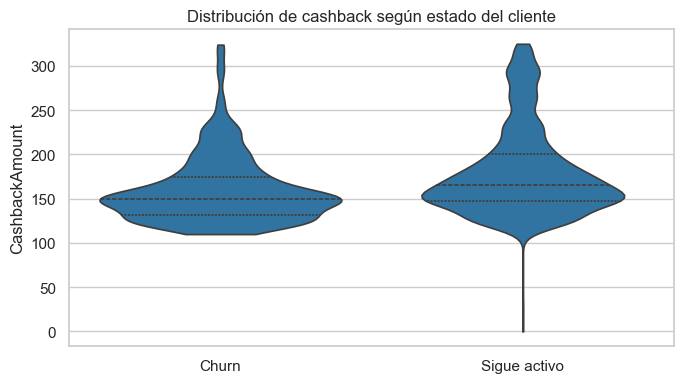

In [60]:
df_cashback = df[["CashbackAmount", "Churn"]].dropna().copy()
df_cashback["estado_cliente"] = df_cashback["Churn"].map({
    0: "Sigue activo",
    1: "Churn"
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.violinplot(
    data=df_cashback,
    x="estado_cliente",
    y="CashbackAmount",
    color="#1f77b4",
    inner="quartile",
    cut=0,
    ax=ax
)

ax.set_title("Distribución de cashback según estado del cliente")
ax.set_xlabel("")
ax.set_ylabel("CashbackAmount")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H5_cashback_violin_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
h5_result = mann_whitney_test(df, "CashbackAmount")
h5_result

{'feature': 'CashbackAmount',
 'test': 'Mann-Whitney U',
 'n_used': 5630,
 'statistic': np.float64(1628104.0),
 'p_value': np.float64(2.223210470400629e-38),
 'effect_size': np.float64(-0.26637792281058437),
 'mean_churn': np.float64(160.36919831223628),
 'mean_no_churn': np.float64(180.63370354549338),
 'median_churn': np.float64(150.0),
 'median_no_churn': np.float64(166.0)}

Los clientes que churnearon muestran un cashback mediano menor que los clientes activos: 150 frente a 166. Esto acompaña la hipótesis de que clientes con menor nivel de beneficios o menor actividad asociada a cashback presentan mayor riesgo de abandono. De todas formas y si bien es estadísticamente significativo la diferencia en términos de señal para la predicción de churn es muy baja por lo que va a ser algo a tener en cuenta pero no importante.

## H6 - DaySinceLastOrder

**Hipotesis:** Los clientes con mas dias desde su ultima orden tienden a churnear mas.

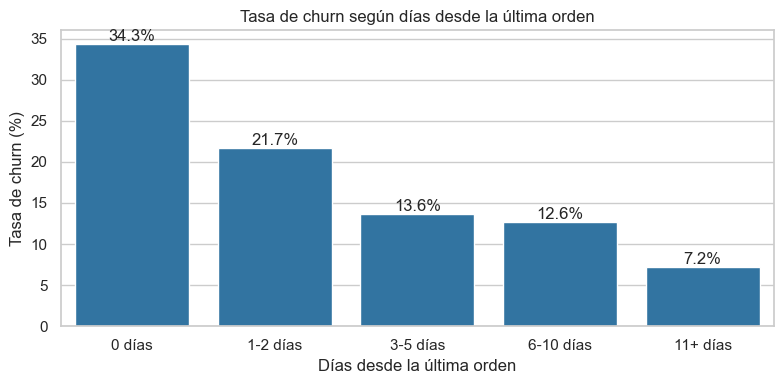

,days_group,clientes,churn_rate_pct
0,0 días,496,34.274194
1,1-2 días,1434,21.687587
2,3-5 días,1678,13.647199
3,6-10 días,1703,12.624780
4,11+ días,319,7.210031


In [59]:
df_days = df[["DaySinceLastOrder", "Churn"]].dropna().copy()

df_days["days_group"] = pd.cut(
    df_days["DaySinceLastOrder"],
    bins=[-1, 0, 2, 5, 10, df_days["DaySinceLastOrder"].max()],
    labels=["0 días", "1-2 días", "3-5 días", "6-10 días", "11+ días"]
)

days_churn = (
    df_days
    .groupby("days_group", observed=True)
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

days_churn["churn_rate_pct"] = days_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=days_churn,
    x="days_group",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según días desde la última orden")
ax.set_xlabel("Días desde la última orden")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H6_days_since_last_order_churn_rate_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

days_churn[["days_group", "clientes", "churn_rate_pct"]]

In [55]:
h6_result = mann_whitney_test(df, "DaySinceLastOrder")
h6_result

{'feature': 'DaySinceLastOrder',
 'test': 'Mann-Whitney U',
 'n_used': 5630,
 'statistic': np.float64(1626085.0),
 'p_value': np.float64(4.396407969758201e-39),
 'effect_size': np.float64(-0.26728768224477617),
 'mean_churn': np.float64(3.4177215189873418),
 'mean_no_churn': np.float64(4.856898761213157),
 'median_churn': np.float64(2.0),
 'median_no_churn': np.float64(4.0)}

La hipótesis no se confirma. Esperábamos que los clientes con más días desde su última orden tuvieran mayor churn, pero en estos datos ocurre lo contrario: los clientes que churnearon tienen una mediana de 2 días desde la última orden, frente a 4 días en clientes activos. Esto sugiere que `DaySinceLastOrder` no debe interpretarse de forma directa como inactividad previa al abandono sin revisar cómo fue medida la variable.